In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
deliveries = pd.read_csv('../data/raw/deliveries.csv')
routes = pd.read_csv('../data/raw/routes.csv')

print(deliveries.shape)
print(routes.shape)

(13, 6)
(4, 3)


In [14]:
deliveries = deliveries.drop_duplicates()
print(deliveries.shape)

(12, 6)


In [15]:
df = deliveries.merge(routes, on='route_id', how='left')

assert df.shape[0] == 12, "Row count is not 12"
assert df['service_type'].isna().sum() == 0, "Unmatched route_id found"

print(df.shape)
print(df.head())

(12, 8)
   record_id month route_id      hub  promised_days  actual_days  \
0          1   Jan       R1   Mumbai              2            2   
1          2   Jan       R2  Chennai              3            4   
2          3   Jan       R3    Delhi              5            8   
3          4   Jan       R4   Mumbai              6           10   
4          5   Feb       R1  Chennai              2            5   

             route service_type  
0       Metro Link      Express  
1        City Dash      Express  
2  Highway Freight     Standard  
3     Rural Feeder     Standard  
4       Metro Link      Express  


In [16]:
df['delay_days'] = (df['actual_days'] - df['promised_days']).clip(lower=0)
print(df[['record_id', 'route_id', 'service_type', 'promised_days', 'actual_days', 'delay_days']])

    record_id route_id service_type  promised_days  actual_days  delay_days
0           1       R1      Express              2            2           0
1           2       R2      Express              3            4           1
2           3       R3     Standard              5            8           3
3           4       R4     Standard              6           10           4
4           5       R1      Express              2            5           3
5           6       R2      Express              3            3           0
6           7       R3     Standard              5           10           5
7           8       R4     Standard              6            7           1
8           9       R1      Express              2            8           6
9          10       R2      Express              3            5           2
10         11       R3     Standard              5            5           0
11         12       R4     Standard              6           15           9


In [17]:
summary = df.groupby('service_type').agg(
    total_delay_days=('delay_days', 'sum'),
    delay_incidence_rate=('actual_days', lambda x: (x > df.loc[x.index, 'promised_days']).mean() * 100)
).reset_index()

print(summary)

  service_type  total_delay_days  delay_incidence_rate
0      Express                12             66.666667
1     Standard                22             83.333333


In [18]:
route_delay = df.groupby('route_id')['delay_days'].sum()
top_route = route_delay.idxmax()
top_route_delay = route_delay.max()
total_delay = df['delay_days'].sum()
share = (top_route_delay / total_delay) * 100

print(f"Top route: {top_route}")
print(f"Delay days: {top_route_delay}")
print(f"Share of total delay: {share:.2f}%")

Top route: R4
Delay days: 14
Share of total delay: 41.18%


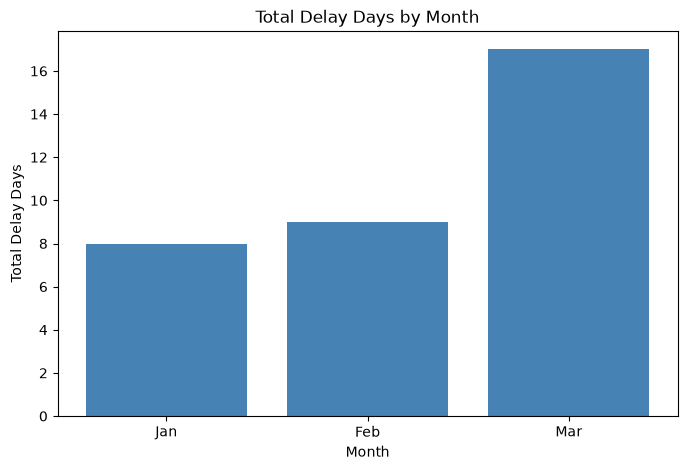

In [19]:
month_order = ['Jan', 'Feb', 'Mar']
monthly = df.groupby('month')['delay_days'].sum().reindex(month_order)

plt.figure(figsize=(8, 5))
plt.bar(monthly.index, monthly.values, color='steelblue')
plt.title('Total Delay Days by Month')
plt.xlabel('Month')
plt.ylabel('Total Delay Days')
plt.savefig('../outputs/python_chart.png')
plt.show()

In [20]:
df.to_csv('../outputs/clean_data.csv', index=False)
summary.to_csv('../outputs/python_summary.csv', index=False)

print("Files exported successfully")

Files exported successfully
